In [ ]:
import os
import pandas as pd
import kagglehub
import ast
# Your existing code to download the dataset
path = kagglehub.dataset_download("thedevastator/english-thai-translation-quality-dataset")

# The name of the file inside the downloaded folder
filename = "train.csv"

# Combine the directory path and the filename to get the full path
full_file_path = os.path.join(path, filename)

print("Full path to the CSV file:", full_file_path)

100%|██████████| 54.0M/54.0M [00:00<00:00, 142MB/s]

Extracting files...


Full path to the CSV file: /root/.cache/kagglehub/datasets/thedevastator/english-thai-translation-quality-dataset/versions/2/train.csv


In [ ]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(full_file_path,on_bad_lines='skip')

# --- Verification ---
print("\n--- First 5 Rows of the Data ---")
print(df.head())


--- First 5 Rows of the Data ---
                                         translation  review_star  correct
0  {'en': "I had a hard time finding a case for m...            4        0
1  {'en': "The story was not bad. However, the ty...            2        0
2  {'en': "This product is completely useless. It...            1        0
3  {'en': "I ordered this for my 2 year old daugh...            4        0
4  {'en': "My children love Jake and the Neverlan...            1        0


In [ ]:
print("Columns found:", df.columns.tolist())
print("-" * 30)
print(df.head())

Columns found: ['translation', 'review_star', 'correct']
------------------------------
                                         translation  review_star  correct
0  {'en': "I had a hard time finding a case for m...            4        0
1  {'en': "The story was not bad. However, the ty...            2        0
2  {'en': "This product is completely useless. It...            1        0
3  {'en': "I ordered this for my 2 year old daugh...            4        0
4  {'en': "My children love Jake and the Neverlan...            1        0


In [ ]:
# 2. แปลงข้อความในคอลัมน์ 'translation' ให้เป็น Dictionary จริงๆ
# ข้อมูลเดิมเป็น String เช่น "{'en': '...', 'th': '...'}" -> แปลงให้ Python เข้าใจว่าเป็น Data Structure
# ใช้ ast.literal_eval จะปลอดภัยและแม่นยำกว่าการตัดคำเอง
df['parsed_translation'] = df['translation'].apply(lambda x: ast.literal_eval(x))

# 3. สร้าง DataFrame ใหม่โดยดึง key 'en' และ 'th' ออกมาเป็นคอลัมน์
clean_df = pd.DataFrame(df['parsed_translation'].tolist())

# ตอนนี้ clean_df จะมีคอลัมน์ 'en' และ 'th' เรียบร้อยแล้ว
print("ตัวอย่างข้อมูลหลังจากแยกคอลัมน์:")
print(clean_df.head())

# 4. เปลี่ยนชื่อคอลัมน์ให้สื่อความหมาย (ถ้าต้องการ)
clean_df.columns = ['English', 'Thai']

# 5. ทำความสะอาดข้อมูล (ลบค่าว่างและค่าซ้ำ)
print(f"จำนวนแถวก่อนคลีน: {len(clean_df)}")
clean_df.dropna(subset=['English', 'Thai'], inplace=True)
clean_df.drop_duplicates(inplace=True)
print(f"จำนวนแถวหลังคลีน:  {len(clean_df)}")

# แสดงผลลัพธ์สุดท้าย
print("-" * 30)
print(clean_df.head())

# 6. (ทางเลือก) บันทึกไฟล์แยก
# clean_df.to_csv("cleaned_en_th.csv", index=False)

ตัวอย่างข้อมูลหลังจากแยกคอลัมน์:
                                                  en  \
0  I had a hard time finding a case for my new LG...   
1  The story was not bad. However, the typos made...   
2  This product is completely useless. It cannot ...   
3  I ordered this for my 2 year old daughter. She...   
4  My children love Jake and the Neverland Pirate...   

                                                  th  
0  ฉันมีปัญหาในการหาเคสสำหรับ LG Lucid 2 ใหม่ของฉ...  
1  เรื่องราวไม่เลว อย่างไรก็ตามการพิมพ์ผิดทำให้มั...  
2  ผลิตภัณฑ์นี้ไร้ประโยชน์อย่างสมบูรณ์ ไม่สามารถใ...  
3  ฉันสั่งสิ่งนี้ให้ลูกสาววัย 2 ขวบของฉัน เธอรักม...  
4  ลูก ๆ ของฉันชอบ Jake และ The Neverland Pirates...  
จำนวนแถวก่อนคลีน: 141369
จำนวนแถวหลังคลีน:  141369
------------------------------
                                             English  \
0  I had a hard time finding a case for my new LG...   
1  The story was not bad. However, the typos made...   
2  This product is completely useless. It cannot .

In [ ]:
import re
from sklearn.model_selection import train_test_split

# Function to clean English text
def clean_english(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special chars (keep numbers & letters)
    text = re.sub(r'\s+', ' ', text).strip() # Remove double spaces
    return text

# Function to clean Thai text (Keep punctuation for Thai usually, or remove if desired)
def clean_thai(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip() # Remove double spaces/newlines
    # Note: We usually don't lowercase Thai as it has no case
    return text

# Apply cleaning
clean_df['English_Clean'] = clean_df['English'].apply(clean_english)
clean_df['Thai_Clean'] = clean_df['Thai'].apply(clean_thai)

print(clean_df.head())

                                             English  \
0  I had a hard time finding a case for my new LG...   
1  The story was not bad. However, the typos made...   
2  This product is completely useless. It cannot ...   
3  I ordered this for my 2 year old daughter. She...   
4  My children love Jake and the Neverland Pirate...   

                                                Thai  \
0  ฉันมีปัญหาในการหาเคสสำหรับ LG Lucid 2 ใหม่ของฉ...   
1  เรื่องราวไม่เลว อย่างไรก็ตามการพิมพ์ผิดทำให้มั...   
2  ผลิตภัณฑ์นี้ไร้ประโยชน์อย่างสมบูรณ์ ไม่สามารถใ...   
3  ฉันสั่งสิ่งนี้ให้ลูกสาววัย 2 ขวบของฉัน เธอรักม...   
4  ลูก ๆ ของฉันชอบ Jake และ The Neverland Pirates...   

                                       English_Clean  \
0  i had a hard time finding a case for my new lg...   
1  the story was not bad however the typos made i...   
2  this product is completely useless it cannot b...   
3  i ordered this for my 2 year old daughter she ...   
4  my children love jake and the neverland pir

In [ ]:
# Split: 80% Train, 10% Validation, 10% Test
train_df, temp_df = train_test_split(clean_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

Training set: 113095
Validation set: 14137
Test set: 14137


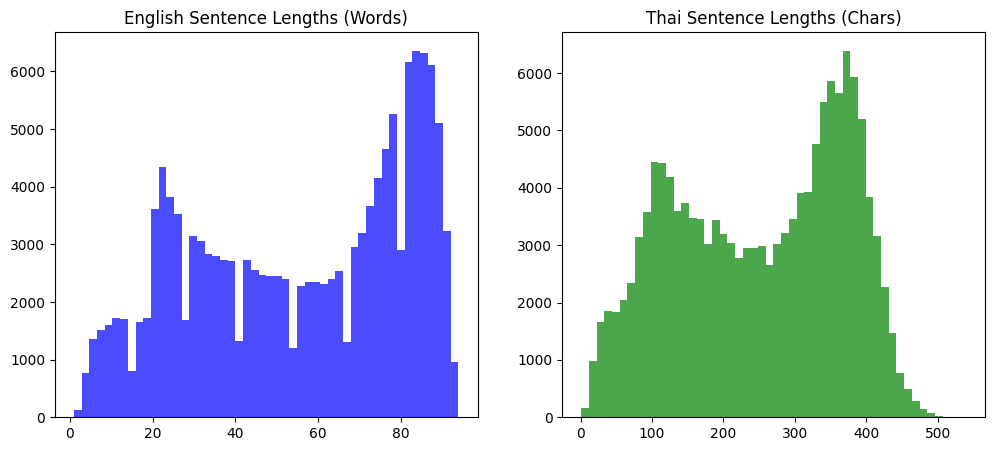

In [ ]:
import matplotlib.pyplot as plt

# Calculate length by character count (or simple word split for EN)
clean_df['en_len'] = clean_df['English_Clean'].str.split().str.len()
clean_df['th_len'] = clean_df['Thai_Clean'].str.len() # Thai length by chars is often better proxy if not segmented

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(clean_df['en_len'], bins=50, color='blue', alpha=0.7)
plt.title('English Sentence Lengths (Words)')

plt.subplot(1, 2, 2)
plt.hist(clean_df['th_len'], bins=50, color='green', alpha=0.7)
plt.title('Thai Sentence Lengths (Chars)')

plt.show()

In [ ]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)